# 00. Setup check

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahleksu/arima-workshop-ccis/blob/main/notebooks/00_setup_check.ipynb)

Run every cell in this notebook before the workshop. It takes about one minute. If a cell fails, read the message under it. On Colab, the first cell installs what is missing.

**What you will check:** package versions, a small ARIMA fit, and the workshop data file.

In [1]:
# Setup. Runs on Google Colab and on a local install.
import importlib.util, subprocess, sys, warnings
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB and importlib.util.find_spec("statsmodels") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.grid": True, "grid.alpha": 0.3})
RAW = "https://raw.githubusercontent.com/ahleksu/arima-workshop-ccis/main/data/"


def _read_energy(path):
    df = pd.read_csv(path, parse_dates=["date"], index_col="date")
    df.index.freq = "D"
    return df


def load_energy():
    """Load the daily energy demand file. Local copy first, then GitHub, then an upload on Colab."""
    name = "energy_demand_daily.csv"
    for base in (Path("../data"), Path("data"), Path(".")):
        if (base / name).exists():
            return _read_energy(base / name)
    try:
        return _read_energy(RAW + name)
    except Exception as exc:
        if not IN_COLAB:
            raise
        print(f"The download failed ({type(exc).__name__}). Choose {name} from your computer or from Drive.")
        from google.colab import files
        files.upload()
        return _read_energy(Path(name))

## 1. Package versions

In [2]:
import statsmodels, scipy, matplotlib
print("Python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scipy       ", scipy.__version__)
print("statsmodels ", statsmodels.__version__)
print("matplotlib  ", matplotlib.__version__)
print("Running on Colab:", IN_COLAB)

Python       3.12.12
numpy        2.5.3
pandas       2.3.3
scipy        1.18.1
statsmodels  0.15.0
matplotlib   3.11.2
Running on Colab: False


## 2. A small ARIMA fit

The cell simulates an AR(1) series with coefficient 0.6 and fits an ARIMA(1,0,0) model. The estimate must land near 0.6.

In [3]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess

rng = np.random.default_rng(42)
sim = ArmaProcess(ar=[1, -0.6], ma=[1]).generate_sample(nsample=1000, distrvs=rng.standard_normal)
fit = ARIMA(sim, order=(1, 0, 0)).fit()
phi = fit.params[1]
print(f"estimated AR(1) coefficient = {phi:.3f} (true value 0.6)")
assert abs(phi - 0.6) < 0.1, "the fit is far from the true value"
print("ARIMA fit works.")

estimated AR(1) coefficient = 0.636 (true value 0.6)
ARIMA fit works.


## 3. The workshop data

The file `energy_demand_daily.csv` holds a synthetic daily electricity demand series. See `data/README.md` for how it was built.

(3653, 3) 2015-01-01 to 2024-12-31


,demand_gwh,temp_c,holiday
date,,,
2015-01-01,1116.81,9.26,1
2015-01-02,1257.05,10.71,0
2015-01-03,1181.13,11.23,0
2015-01-04,1180.73,10.03,0
2015-01-05,1255.23,8.15,0


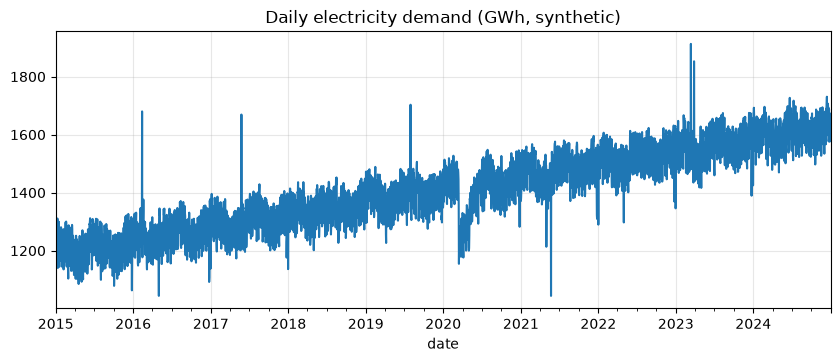

In [4]:
energy = load_energy()
print(energy.shape, energy.index.min().date(), "to", energy.index.max().date())
display(energy.head())
energy["demand_gwh"].plot(title="Daily electricity demand (GWh, synthetic)")
plt.show()

If you see a chart above and no error, your setup works. Continue with notebook 01.